# Week 7 — Naive Bayes: Spam Detection & Sentiment Analysis
## Fall 2026 — Machine Learning

## Student Information
Name:Suneel kumar

Student ID:023-24-0527

Section:B

GitHub:

Kaggle:

**Datasets:** SMS Spam Collection; Twitter US Airline Sentiment

**Dataset Sources:**
- Task A: Kaggle — https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
- Task B: Kaggle — https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

**Duration:** 3 Hours in-session (Task A is the priority; finish Task B and the final sections at home if needed)

> This notebook is a **template**, not a tutorial. You already know Naive Bayes theory. Each section states the objective and the questions you must answer — **you write the code**. Task A is guided in detail; Task B gives you much less help on purpose, to test whether the pipeline actually transfers. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [174]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns


---

## 1. Problem Definition & Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.head()`, `df['label'].value_counts()`

**Tasks**
1. Load both datasets (`spam.csv` for Task A, `Tweets.csv` for Task B). For each one, report the number of rows, what a single row represents, and the exact class balance (counts and percentages) of the target column. Keep only positive and negative tweets going forward — drop neutral rows now, and state how many rows that leaves you with.
2. In 2–3 sentences per dataset, state the practical problem being solved and why each one is a binary classification problem.

In [175]:
# Task 1 — load spam.csv, inspect shape/head/class balance
df = pd.read_csv("spam.csv", encoding="latin-1")
print(df)
print(df.shape)
df.head()

        v1                                                 v2 Unnamed: 2  \
0      ham  Go until jurong point, crazy.. Available only ...        NaN   
1      ham                      Ok lar... Joking wif u oni...        NaN   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3      ham  U dun say so early hor... U c already then say...        NaN   
4      ham  Nah I don't think he goes to usf, he lives aro...        NaN   
...    ...                                                ...        ...   
5567  spam  This is the 2nd time we have tried 2 contact u...        NaN   
5568   ham              Will Ì_ b going to esplanade fr home?        NaN   
5569   ham  Pity, * was in mood for that. So...any other s...        NaN   
5570   ham  The guy did some bitching but I acted like i'd...        NaN   
5571   ham                         Rofl. Its true to its name        NaN   

     Unnamed: 3 Unnamed: 4  
0           NaN        NaN  
1           NaN        NaN  


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [187]:
# Task 1 (continued) — load Tweets.csv, drop neutral, inspect shape/head/class balance
df2=pd.read_csv("Tweets.csv")

**Answer 2 (Task A — spam):**
_(your answer here)_

**Answer 2 (Task B — sentiment):**
_(your answer here)_

---

## 2. Task A: Text Cleaning & Vectorization (Spam)

*Concepts/functions you may find useful:* `text.str.lower()`, `CountVectorizer` / `TfidfVectorizer`, `vectorizer.fit_transform(X_train)`, `vectorizer.transform(X_test)`, `vectorizer.get_feature_names_out()`

**Tasks**
3. Lightly clean the message text (lowercase at minimum). Keep this simple.
4. Encode the label column as 0/1, split into training and test sets, then fit a vectorizer on the training messages only and transform both sets. Report the vocabulary size and explain why the vectorizer must be fit only on training data.

In [177]:
# Task 3 — clean text
df = df[['v1', 'v2']]
df['v2'] = df['v2'].str.lower()
df.head()

,v1,v2
0,ham,"go until jurong point, crazy.. available only ..."
1,ham,ok lar... joking wif u oni...
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor... u c already then say...
4,ham,"nah i don't think he goes to usf, he lives aro..."


In [178]:
# Task 4 — encode labels, split, fit vectorizer on train only, transform both sets
df['v1'] = df['v1'].map({'ham': 0,'spam': 1})

X = df['v2']
y = df['v1']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)

X_test_vec = vectorizer.transform(X_test)

vocab_size = len(vectorizer.get_feature_names_out())
print("Vocabulary size:", vocab_size)

Vocabulary size: 7701


**Answer 4 (why fit on training data only):**
_(your answer here)_

---

## 3. Task A: Naive Bayes Model & Evaluation (Spam)

*Concepts/functions you may find useful:* `MultinomialNB()`, `.fit()`, `.predict()`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`

**Tasks**
5. Train a `MultinomialNB` model on the vectorized training data. Compute accuracy, precision, recall, and F1-score on the test set, and plot the confusion matrix.
6. Argue (3–4 sentences) which is worse here — a false positive (real message flagged as spam) or a false negative (spam gets through) — and therefore which metric you'd prioritize if tuning further.

Accuracy:  0.9605381165919282
Precission:  1.0
Recall:  0.7046979865771812
F1 score:  0.8267716535433071
[[966   0]
 [ 44 105]]


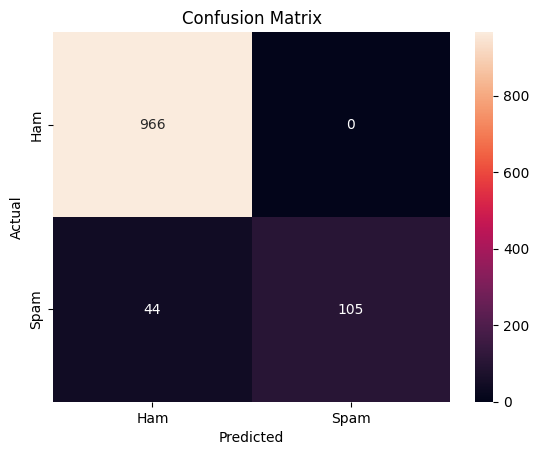

In [179]:
# Task 5 — train MultinomialNB, compute metrics, plot confusion matrix
model = MultinomialNB()

model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

accuracy=accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

precission=precision_score(y_test, y_pred)
print("Precission: " , precission)

recall=recall_score(y_test, y_pred)
print("Recall: ", recall)

f1=f1_score(y_test, y_pred)
print("F1 score: " , f1)

print(confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**Task 5 — Spam Model Metrics**

| Metric | Value |
|---|---|
| Accuracy |0.96 |
| Precision |1.0 |
| Recall |0.70|
| F1-score |0.82 |

**Answer 6:**
The Multinomial Naive Bayes model achieved 96% accuracy and 100% precision. This means most messages were classified correctly, and every message predicted as spam was actually spam. However, the recall was approximately 70%, meaning the model detected about 70% of the actual spam messages and missed some spam messages. The F1-score of approximately 0.83 reflects the balance between precision and recall.

---

## 4. Task A: Word Interpretation (Spam)

*Concepts/functions you may find useful:* `model.feature_log_prob_`, `np.argsort(...)`

**Tasks**
7. Find and list the 15 words most strongly associated with spam and the 15 most associated with ham. Do these match your intuition?
8. Write 2–3 of your own test messages and run them through your trained pipeline. Do the predictions match what you expected?

In [180]:
# Task 7 — extract top spam words and top ham words from feature_log_prob_
# Get vocabulary words
features = vectorizer.get_feature_names_out()

# Get learned log probabilities
log_probs = model.feature_log_prob_

# Row 0 = ham
ham_probs = log_probs[0]

# Row 1 = spam
spam_probs = log_probs[1]

# Top 20 spam words
top_spam_indices = np.argsort(spam_probs)[-20:][::-1]
top_spam_words = features[top_spam_indices]

# Top 20 ham words
top_ham_indices = np.argsort(ham_probs)[-20:][::-1]
top_ham_words = features[top_ham_indices]

print("Top 20 Spam Words:")
print(top_spam_words)

print("\nTop 20 Ham Words:")
print(top_ham_words)

Top 20 Spam Words:
['to' 'call' 'free' 'your' 'you' 'txt' 'now' 'for' 'or' 'claim' 'from'
 'the' 'mobile' 'stop' 'ur' 'text' 'is' 'have' 'reply' 'www']

Top 20 Ham Words:
['you' 'to' 'the' 'in' 'me' 'my' 'and' 'it' 'is' 'ok' 'that' 'are' 'can'
 'so' 'not' 'have' 'for' 'do' 'of' 'at']


**Answer 7:**
_(your answer here)_

In [185]:
# Task 8 — test your own messages

my_messages = [
     "Congratulations! You have won a free prize. Call now to claim your reward!",
    "You are the lucky winner of a free iPhone. Reply YES to receive your prize!",
    "it is ok",
]

# Clean messages
my_messages = [msg.lower() for msg in my_messages]

# Convert text using the already-fitted vectorizer
my_messages_vec = vectorizer.transform(my_messages)

# Predict
my_predictions = model.predict(my_messages_vec)

# Display predictions
for message, prediction in zip(my_messages, my_predictions):
    label = "Spam" if prediction == 1 else "Ham"
    print(f"{message} → {label}")


congratulations! you have won a free prize. call now to claim your reward! → Spam
you are the lucky winner of a free iphone. reply yes to receive your prize! → Spam
it is ok → Ham


**Answer 8:**
_(your answer here)_

---

## 5. Task A: Kaggle Notebook Submission

Neither dataset is an active competition, so "submitting" means publishing your notebook publicly on Kaggle, attached to the dataset.

**Tasks**
9. Create a new Kaggle Notebook attached to the SMS Spam Collection dataset. Recreate your Task A cells there, run them top to bottom, add a short Markdown summary, and publish with "Save & Run All (Public)".
10. Record the public notebook URL below.

**Task A Kaggle Notebook URL:**
https://www.kaggle.com/code/suneelwadhwani/notebook304b778523

---

## 6. Task B: Text Cleaning & Vectorization (Sentiment)

Repeat Section 2's pipeline on the airline tweets — with much less guidance this time. Tweets contain @mentions, links, and hashtags that SMS messages didn't.

**Tasks**
11. Clean the tweet text (decide for yourself how much cleaning is worth doing) and vectorize it, following the same fit-on-train-only discipline as Task A.
12. Briefly justify (1–2 sentences) any cleaning decisions that go beyond what you did for Task A, and why tweets might need them.

In [188]:
# Task 11 — clean and vectorize the sentiment data (your own approach)
df2.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


**Answer 12:**
_(your answer here)_

---

## 7. Task B: Naive Bayes Model & Evaluation (Sentiment)

**Tasks**
13. Train a `MultinomialNB` model on the vectorized tweet data. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
14. Compare these metrics to Task A's. Did Naive Bayes do better or worse on sentiment than on spam? Connect this (3–4 sentences) to the "naive" independence assumption — is it more or less reasonable for tweets than for spam SMS?

In [183]:
# Task 13 — train MultinomialNB, compute metrics, plot confusion matrix


**Task 13 — Sentiment Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | |
| Precision | |
| Recall | |
| F1-score | |

**Answer 14:**
_(your answer here)_

---

## 8. Task B: Kaggle Notebook Submission

**Tasks**
15. Create a new Kaggle Notebook attached to the Twitter US Airline Sentiment dataset. Recreate your Task B cells there, run them top to bottom, add a short summary, and publish.
16. Record the public notebook URL below.

**Task B Kaggle Notebook URL:**
_(paste your published notebook link here)_

---

## 9. Cross-Task Comparison & vs. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression(max_iter=1000)` trained on the same vectorized features

**Tasks**
17. Build a table comparing Naive Bayes on Task A vs. Task B (accuracy, precision, recall, F1).
18. Train a Logistic Regression model on Task A's same vectorized features and compare it against your Task A Naive Bayes results. Which model wins, and does that match what you'd expect?

**Task 17 — Task A vs. Task B (Naive Bayes)**

| Metric | Task A (Spam) | Task B (Sentiment) |
|---|---|---|
| Accuracy | | |
| Precision | | |
| Recall | | |
| F1-score | | |

In [184]:
# Task 18 — train Logistic Regression on Task A's vectorized features


**Task 18 — Naive Bayes vs. Logistic Regression (Task A)**

| Metric | Naive Bayes | Logistic Regression |
|---|---|---|
| Accuracy | | |
| Precision | | |
| Recall | | |
| F1-score | | |

**Answer 18 (which wins, and does it match expectations):**
_(your answer here)_

---

## 10. Final Reflection & Conclusion

**Tasks**
19. Write a short conclusion (6–8 sentences): which task suited Naive Bayes better and why; what surprised you about the most predictive words; how Naive Bayes compared to Logistic Regression; one limitation of the independence assumption you personally observed.
20. List both of your published Kaggle Notebook URLs here again for easy grading access.

**Answer 19 — Conclusion:**
_(your answer here)_

**Answer 20 — Kaggle Notebook Links:**
- Task A: _______
- Task B: _______

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, both datasets)
- [ ] Section 1 — Problem Definition & Dataset Exploration (both datasets, neutral tweets dropped)
- [ ] Section 2 — Task A Cleaning & Vectorization (fit on training data only)
- [ ] Section 3 — Task A Model & Evaluation (all four metrics + confusion matrix + precision/recall argument)
- [ ] Section 4 — Task A Word Interpretation (top words + your own test messages)
- [ ] Section 5 — Task A Kaggle Notebook published and linked
- [ ] Section 6 — Task B Cleaning & Vectorization (cleaning choices justified)
- [ ] Section 7 — Task B Model & Evaluation (all four metrics + independence-assumption discussion)
- [ ] Section 8 — Task B Kaggle Notebook published and linked
- [ ] Section 9 — Cross-Task Comparison & vs. Logistic Regression
- [ ] Section 10 — Final Reflection & Conclusion (both Kaggle links listed again)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted